# Исследование тикетов из службы поддержки

- Автор: Агансонов Руслан
- Дата: 28.05

## Введение

### Цель исследования

**Цель:** Провести комплексный дата-анализ сквозного жизненного цикла обращений в службе технической поддержки для оценки операционной эффективности процессов, аудита продуктивности персонала и выявления скрытых системных аномалий с использованием инструментов SQL и Python (Pandas, Seaborn, Matplotlib).

### Задачи исследования

- Провести предобработку данных, убрать дублирующие строки и пропуски.
- Выделить группы тикетов по категориям обращений и сравнить их по количеству заявок и затраченному времени на решение.
- Определить типичные и аномальные значения времени решения тикетов (выявить баги с датами), исключить выбросы.
- Проанализировать календарную (по дням недели) и суточную (по часам) динамику поступления задач для выявления периодов пиковой нагрузки и организационных аномалий.
- Оценить скорость закрытия заявок в разрезе различных временных интервалов (<1 дня, 1-7 дней, >7 дней) и проанализировать влияние приоритетов на скорость обработки.
- Изучить персональные показатели выработки и успешности закрытия заявок у инженеров поддержки для оценки сбалансированности команды и качества автоматического распределения задач.
- Проанализировать динамику накопления нерешённых задач (бэклога) для выявления периодов кризиса пропускной способности.
- Подвести итоговые выводы и дать рекомендации, в какие категории и процессы было бы целесообразно направить ресурсы для оптимизации работы техподдержки.


### Содержимое исследования

1. Знакомство с данными
2. Выполнение расчетов с помощью Python
3. Выполнение части расчетов с помощью SQLite
4. Итоговый вывод и рекомендации

## Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных системы обработки тикетов.

Название основного датасета - `final_dataset.csv`. Он содержит информацию о всех тикетах службы поддержки за июнь 2023 года.

Описание данных:
* `created` — дата создания тикета в UNIX-формате.
* `key` — номер запроса в базе данных.
* `resolution` — айди категории решения тикета, внешний ключ к другому датасету.
* `resolved` — дата решения тикета в UNIX-формате.
* `category` — категория проблемы в тикете.
* `resolution_category` — категория решения тикета.
* `priority` — приоритет выполнения тикета.
* `assignee_id` — сотрудник, решающий задачу.
  
### Вывод общей информации

Загрузим необходимые для работы библиотеки.


In [80]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import sqlite3

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

Выгрузим данные в переменные с помощью Pandas:

In [81]:
# Выгружаем данные в переменную df, а также создадим копию df - df_copy на будущее
df = pd.read_csv("final_dataset.csv", sep=',', low_memory=False)
df_copy = df.copy()

Выведем информацию, которая необходима для принятия решений о предобработке. Познакомимся с данными датасета `final_dataset.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [82]:
# Выводим первые строки датафрейма на экран
df.head()

,created,key,resolution,resolved,category,resolution_category,priority,assignee_id
0,1.685582e+12,CRAZY-1787362,4f6b29cc3004e9443e453da7,1.685630e+12,Remote,Successful,Low,DEV-1017
1,1.685582e+12,CRAZY-1787363,4f6b29cc3004e9443e453da7,1.685583e+12,Remote,Successful,Critical,DEV-1043
2,1.685582e+12,CRAZY-1787364,4f6b29cc3004e9443e453da7,1.685583e+12,Remote,Successful,Medium,DEV-1042
3,1.685585e+12,CRAZY-1787366,4f6b29cc3004e9443e453da7,1.685635e+12,Remote,Successful,Medium,DEV-1015
4,1.685585e+12,CRAZY-1787368,4f6b29cc3004e9443e453da7,1.685635e+12,Remote,Successful,Low,DEV-1025


In [83]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51955 entries, 0 to 51954
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   created              51952 non-null  float64
 1   key                  51954 non-null  object 
 2   resolution           49189 non-null  object 
 3   resolved             49189 non-null  float64
 4   category             51955 non-null  object 
 5   resolution_category  49188 non-null  object 
 6   priority             51955 non-null  object 
 7   assignee_id          51955 non-null  object 
dtypes: float64(2), object(6)
memory usage: 3.2+ MB


Датасет `final_dataset.csv` (в коде df) содержит 8 столбцов и 51955 строк, в которых представлена информация о созданных тикетах и их статусах.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов изначально приведены к нужному формату и стилю (нижний регистр, без пробелов).
- Представленные данные содержат числовые и строковые значения, которые хранятся в типах данных float64 или object. Значения в столбце `category` представлены в виде строк, однако характеризуют какую-либо категорию - тип данных для таких столбцов можно оптимизировать. Столбцы `created` и `resolved` хранят время в формате UNIX, но имеют тип float64 - их нужно будет привести к формату даты и времени (datetime).
- Пропуски содержатся почти во всех столбцах, кроме `category`, `priority` и `assignee_id`. Больше всего пропущенных значений в столбцах `resolution`, `resolved` и `resolution_category` (по 2766-2767 пропусков), что, вероятно, говорит о тикетах, которые еще находятся в работе и не имеют статуса закрытия.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Первичное знакомство с помощью python показывает, что данные хорошего качества - в них присутствуют пропущенные значения (что обосновано бизнес-логикой открытых тикетов), а сами данные соответствуют описанию и выглядят корректными, но требуют корректировки типов данных для времени. Настало время следующего этапа - предобработки данных.

### Вывод общей информации

Проверим названия столбцов в датасетах: все ли они точно отражают
содержимое данных и оформлены в удобном для работы стиле. При
необходимости приведем их к единому аккуратному стилю.


Приведем столбец created и resolved к нужному типу данных в виде datetime:

In [5]:
#Приведем столбец created и resolved к нужному числовому типу
df['created'] = pd.to_datetime(df['created'], unit='ms', errors='coerce')
df['resolved'] = pd.to_datetime(df['resolved'], unit='ms', errors='coerce')

Перед тем как приводить столбец category к типу данных category, проверим
количество уникальных элементов в нем:

In [6]:
df['category'].nunique()

4

Количество уникальных данных небольшое, значит можно привести к нужному
типу данных:

In [7]:
df['category'] = df['category'].astype('category')

Приведем столбцы resolution_category и priority аналогично к category:

In [85]:
print(df['resolution_category'].nunique())
df['priority'].nunique()

3


4

In [86]:
df['resolution_category'] = df['resolution_category'].astype('category')

In [87]:
df['priority'] = df['priority'].astype('category')

Выведем информацию об измененном датафрейме df_issues:

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51955 entries, 0 to 51954
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   created              51952 non-null  float64 
 1   key                  51954 non-null  object  
 2   resolution           49189 non-null  object  
 3   resolved             49189 non-null  float64 
 4   category             51955 non-null  object  
 5   resolution_category  49188 non-null  category
 6   priority             51955 non-null  category
 7   assignee_id          51955 non-null  object  
dtypes: category(2), float64(2), object(4)
memory usage: 2.5+ MB


Перейдем к датафрейму df_resolutions. Исправим название столбца key на result:

In [89]:
df.rename(columns={'resolution_category': 'result'}, inplace=True)

Обработаем пропуски в столбцах датафрейма df_issues:

In [90]:
#Удалим строки со всеми пропусками в столбцах
df.dropna(how='all', inplace=True)

In [91]:
#Проверим есть ли пустые значения в столбце с названием компаний
df['created'].isna().sum()

np.int64(3)

Обработаем полные дубликаты в данных и пропуски в created (избавимся от тех
строк, которые не несут какой-либо информации либо не содержат данных о
дате создания тикета).

In [92]:
df[df['created'].isna()]

,created,key,resolution,resolved,category,result,priority,assignee_id
1199,NaN,CRAZY-1788588,4f6b29cc3004e9443e453da7,1.686060e+12,Local,Successful,Low,DEV-1005
1200,NaN,CRAZY-1788589,4f6b29cc3004e9443e453da7,1.685626e+12,Local,Successful,Medium,DEV-1024
1201,NaN,CRAZY-1788590,4f6b29cc3004e9443e453da7,1.686732e+12,Local,Successful,Low,DEV-1046


In [93]:
#Удалим данные строки из исходного датасета, так как в нем нет информации о дате создания тикета
df.dropna(subset=['created'], inplace=True)

In [94]:
#Уберем из датафрейма полные дубликаты строк
df.drop_duplicates(inplace=True)

In [95]:
#Проверим количество дубликатов в готовом датасете
df.duplicated().sum()

np.int64(0)

In [96]:
#Оценим полученный датасет после выполнения предобработки
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51952 entries, 0 to 51954
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   created      51952 non-null  float64 
 1   key          51951 non-null  object  
 2   resolution   49186 non-null  object  
 3   resolved     49186 non-null  float64 
 4   category     51952 non-null  object  
 5   result       49185 non-null  category
 6   priority     51952 non-null  category
 7   assignee_id  51952 non-null  object  
dtypes: category(2), float64(2), object(4)
memory usage: 2.9+ MB


Таким образом, доля полученных данных после предобработки составляет:

In [97]:
df.shape[0]/df_copy.shape[0]

0.9999422577230296

Оценим полноту данных и сделаем предварительный вывод о том, достаточно
ли данных для решения задач проекта.
В ходе предобработки данных была проведено изменение названия столбца,
изменение типов данных (включая перевод дат в формат datetime и перевод в
категориальный тип данных), а также обработка пропусков.
После удаления полных дубликатов и строк с критическими пропусками в
столбце 'created' было сохранено 99,99% от исходного датасета. Таким
образом, доля удаленных данных составила около 0,01%. Количество
удаленных данных является незначительным, значит полнота данных
сохранена.

## Выполнение расчетов с помощью Pandas

Для выполнения расчетов скопируем полученный после предобработки датасет:

In [22]:
df_resulted = df.copy()

### Поиск доли тикетов в одном месяце

В этой части проводится расчет ключевого операционного показателя - доли
тикетов, работа над которыми была полностью завершена в течение того же
календарного месяца, когда они поступили в систему. Анализ данной метрики
позволяет объективно оценить скорость реакции службы поддержки на
входящий поток обращений и выявить эффективность обработки заявок без
накопления критического объема отложенных задач.

In [98]:
#Отфильтруем данные по одинаковому месяцу выполнения тикета
same_month_resolution = (
 df_resulted['resolved'].notna() &
 (df_resulted['created'].dt.to_period('M') == df_resulted['resolved'].dt.to_period('M'))
)
#Расчет доли в процентах
share_pct = (same_month_resolution.sum() / len(df_resulted)) * 100
print(f"Доля тикетов, решённых в тот же месяц: {share_pct:.2f}%")

Доля тикетов, решённых в тот же месяц: 90.38%


Высокий показатель в 90.38% свидетельствует об отличной операционной
эффективности. Подавляющее большинство заявок закрывается без переноса
на следующий месяц, что минимизирует накопление хвостов и говорит о
достаточности ресурсов команды для текущего потока задач. Для наибольшей
эффективности необходимо проанализировать данную метрику в сравнении с
другими месяцами работы.


### Количество решённых тикетов с группировкой по именам резолюций

Данный раздел посвящен анализу качественных результатов работы над
тикетами через распределение их финальных статусов по именам резолюций.
Группировка данных в этом разрезе позволяет детально изучить структуру
завершенных задач и определить, какой объем нагрузки завершается
фактическим исправлением (Successful), а какая часть приходится на
альтернативные действия.

In [99]:
#Оставляем только те тикеты, у которых заполнена дата решения
resolved_only = df_resulted[df_resulted['resolved'].notna()]

#Группируем по резолюциям
resolution_stats = (
    resolved_only.groupby('result', as_index=False, observed=True)
    .size()
    .rename(columns={'size': 'ticket_count'})
)

#Добавляем долю в процентах
total_tickets = resolution_stats['ticket_count'].sum()
resolution_stats['share_pct'] = (resolution_stats['ticket_count'] / total_tickets * 100).round(2)

#Сортируем по убыванию и сбрасываем индексы
resolution_stats = resolution_stats.sort_values(by='ticket_count', ascending=False, ignore_index=True)

# Выводим результат
resolution_stats

,result,ticket_count,share_pct
0,Successful,47600,96.78
1,Rejected,1545,3.14
2,Other,39,0.08


Визуализируем полученную таблицу с помощью барплота:

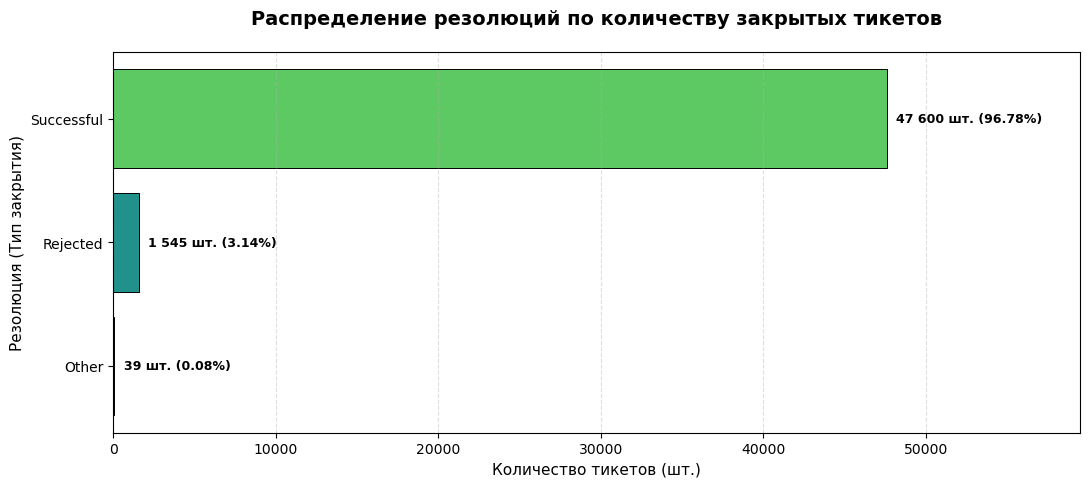

In [100]:
#Инициализируем график
fig, ax = plt.subplots(figsize=(11, 5))
plot_data = resolution_stats.iloc[::-1]

#Строим горизонтальный барплот напрямую
bars = ax.barh(
    plot_data['result'], 
    plot_data['ticket_count'], 
    color=['#440154', '#21918c', '#5dc963'],  # Цвета из палитры viridis
    edgecolor='black',
    linewidth=0.7
)

#Расширяем ось X под текст
ax.set_xlim(0, plot_data['ticket_count'].max() * 1.25)

#Генерируем подписи
labels = [
    f"{int(row['ticket_count']):,} шт. ({row['share_pct']:.2f}%)".replace(',', ' ')
    for _, row in plot_data.iterrows()
]
ax.bar_label(
    bars, 
    labels=labels, 
    label_type='edge', 
    padding=7, 
    fontsize=9, 
    fontweight='bold'
)

#Оформление графика
ax.set_title('Распределение резолюций по количеству закрытых тикетов', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Количество тикетов (шт.)', fontsize=11)
ax.set_ylabel('Резолюция (Тип закрытия)', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Анализ распределения резолюций наглядно демонстрирует, что подавляющее
большинство решенных тикетов (более 96%) завершается статусом Successful, что
свидетельствует об эффективном устранении возникающих проблем. Крайне
низкая доля отклонений (Rejected) и других ошибок (Other) указывает на
качественную работу первой линии поддержки и отлаженную систему
модерации входящих заявок.

### Поиск закономерностей в распределении категорий в тикетах

В данной пункте мы переходим от оценки общих метрик эффективности к
детальному исследовательскому анализу в разрезе категорий обращений.
Наша главная цель на этом этапе - декомпозировать входящий поток задач и
понять, как специфика проблемы влияет на жизненный цикл тикета

Рассчитаем количество тикетов для каждой категории в абсолютном и относительном виде.

In [101]:
#Рассчитаем количество тикетов с помощью value_counts
category_dist = df_resulted['category'].value_counts().reset_index()
category_dist.columns = ['category', 'total_tickets']
category_dist['share_pct'] = (category_dist['total_tickets'] / len(df_resulted) * 100).round(2)
category_dist

,category,total_tickets,share_pct
0,Local,26366,50.75
1,Remote,18169,34.97
2,New User,6144,11.83
3,Software License,1273,2.45


Визуализируем данную сводную таблицу с помощью гистограммы:

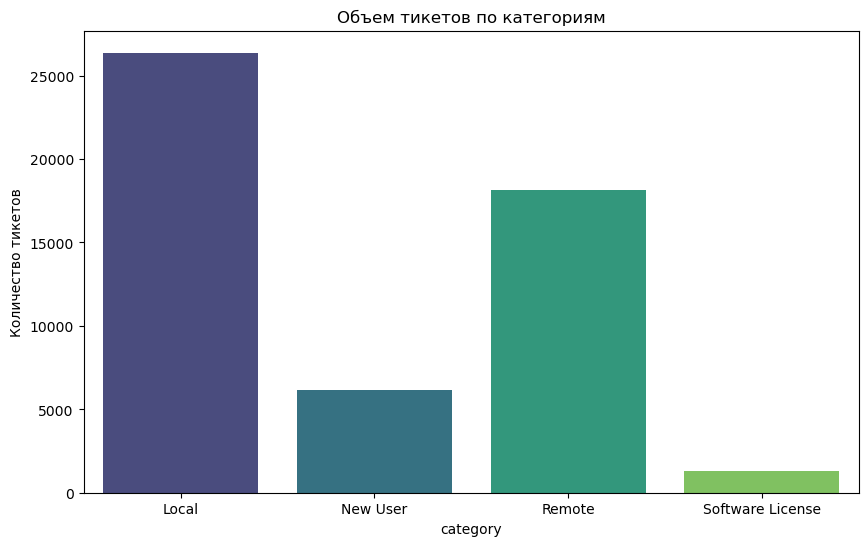

In [102]:
#Используем гистограмму для визуализации данных
plt.figure(figsize=(10, 6))
sns.barplot(
 data=category_dist,
 x='category',
 y='total_tickets',
 hue='category',
 palette='viridis',
 legend=False
)
#Оформление графика
plt.title('Объем тикетов по категориям')
plt.ylabel('Количество тикетов')
plt.show()

Анализ объема тикетов показывает, что категория Local является абсолютным
лидером по количеству обращений, значительно опережая остальные
сегменты. Вместе с категорией Remote они формируют основную нагрузку на
службу поддержки, в то время как вопросы лицензирования (Software License)
занимают минимальную долю в общей структуре.

Рассмотрим более детально, просмотрев процент закрытия тикетов, процент успешного закрытия тикетов и среднее время закрытия тикетов данной категории:

In [103]:
#Скопируем исходный датасет в другую переменную
df = df_resulted.copy()
df['res_time_hours'] = (df['resolved'] - df['created']).dt.total_seconds() / 3600
#Посчитаем базовые метрики для каждой категории
result = df.groupby('category', observed=False).agg(
 total_tickets=('key', 'count'),
 resolved_count=('resolved', 'count'),
 fixed_count=('result', lambda x: (x == 'Successful').sum()),
 avg_resolution_time_hours=('res_time_hours', 'mean')
).reset_index()
#Расчет производных метрик
total_sum_tickets = result['total_tickets'].sum()
result['pct_of_total_volume'] = (result['total_tickets'] / total_sum_tickets) * 100
result['resolution_rate_pct'] = (result['resolved_count'] / result['total_tickets']) * 100 #Подсчет
result['fixed_rate_pct'] = (result['fixed_count'] / result['resolved_count']) * 100 #Подсчет тикето
result = result.sort_values(by='total_tickets', ascending=False)
#Отфильтруем нужные столбцы и отсортируем таблицу
final_columns = [
 'category', 'total_tickets', 'pct_of_total_volume',
 'resolution_rate_pct', 'fixed_rate_pct', 'avg_resolution_time_hours'
]
result = result[final_columns].reset_index(drop=True)
result

,category,total_tickets,pct_of_total_volume,resolution_rate_pct,fixed_rate_pct,avg_resolution_time_hours
0,Local,26366,50.751670,94.693924,96.643570,39.413213
1,Remote,18168,34.971415,94.253633,96.700537,96.272862
2,New User,6144,11.826529,94.742839,96.976465,38.433228
3,Software License,1273,2.450386,100.000000,99.607227,0.004386


Среднее время ответа на тикет довольно велико, проверим медиану, 90-й и
95-й перцентили для уточнения распределения закрытия тикетов:


In [104]:
#Сгруппируем данные по категории и найдем нужные перцентили
percentiles = df.groupby('category', observed=False)['res_time_hours'].quantile([0.5, 0.9, 0.95]).unstack()

#Переименуем получившиеся столбцы
percentiles.columns = ['Медиана', '90-й перцентиль', '95-й перцентиль']
percentiles

,Медиана,90-й перцентиль,95-й перцентиль
category,,,
Local,0.181384,136.708075,268.627310
New User,0.177910,143.503113,237.348682
Remote,0.229508,150.643351,262.952259
Software License,0.004309,0.006635,0.007423


Количественный анализ подтверждает, что категории Local и Remote являются
критическими точками нагрузки, аккумулируя более 85% всего объема заявок.
Подавляющее большинство заявок обрабатывается крайне оперативно.
Огромные средние значения (39 часов для Local и 96 часов для Remote)
формируются исключительно за счет 5–10% зависших тикетов. Медианное
время (50% всех тикетов) для категорий Local, Remote и New User составляет
всего от 0.17 до 0.22 часа (около 10–13 минут). Это означает, что первая линия
поддержки или базовые скрипты работают очень эффективно и закрывают
половину потока почти мгновенно.
Также, можно сказать точно, что сектор Software License практически
полностью автоматизирован с мгновенным закрытием тикетов. Тем не менее,
стабильно высокий уровень успешного решения задач (Resolution Rate > 94%)
во всех категориях свидетельствует о надежности выстроенных процессов,
даже в сегментах с длительным циклом обработки

Теперь перейдем к рассмотрению количества тикетов для каждой категории по дням недели:

In [105]:
dt_col = df_resulted['created']

#Вычисляем номер дня недели
df_resulted['dow_num'] = (dt_col.dt.weekday + 1) % 7

#Задаем словарь для перевода чисел в названия дней
days_map = {
    0: 'Воскресенье',
    1: 'Понедельник',
    2: 'Вторник',
    3: 'Среда',
    4: 'Четверг',
    5: 'Пятница',
    6: 'Суббота'
}
df_resulted['day_of_week'] = df_resulted['dow_num'].map(days_map)

#Группируем, считаем, сортируем и чистим результат
result = (
    df_resulted.groupby(['category', 'day_of_week', 'dow_num'], as_index=False, observed=True)  # <-- Добавили observed=True
    .size()                                          
    .rename(columns={'size': 'ticket_count'})        
    .sort_values(by=['category', 'dow_num'])         
    [['category', 'day_of_week', 'ticket_count']]    
    .reset_index(drop=True)                          
)
result

,category,day_of_week,ticket_count
0,Local,Воскресенье,1141
1,Local,Понедельник,5957
2,Local,Среда,6280
3,Local,Четверг,6557
4,Local,Пятница,5709
5,Local,Суббота,722
6,New User,Вторник,6144
7,Remote,Воскресенье,474
8,Remote,Понедельник,2909
9,Remote,Вторник,3256


Для наглядности визуализируем полученный датафрейм:

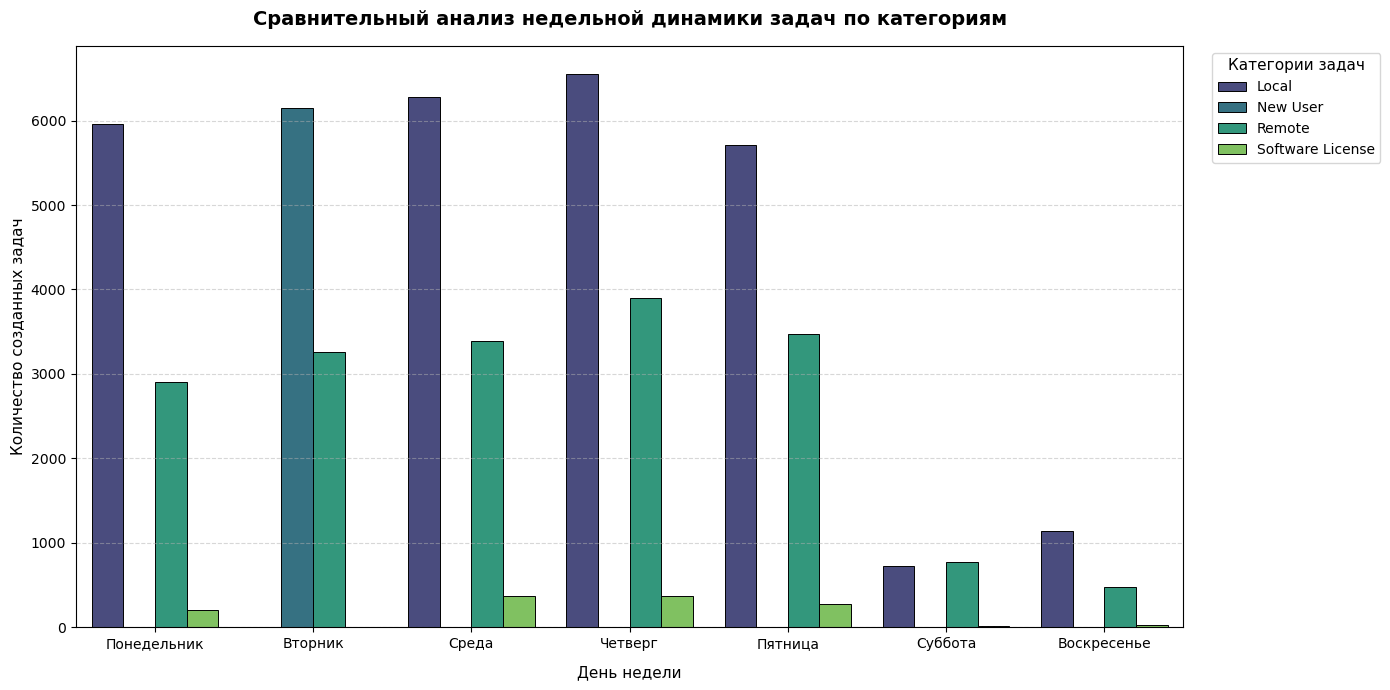

In [106]:
days_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

plt.figure(figsize=(14, 7))
#Строим группированную столбчатую диаграмму по датафрейму result
sns.barplot(
    data=result,
    x='day_of_week',
    y='ticket_count',
    hue='category', 
    order=days_order, 
    palette='viridis',
    edgecolor='black',
    linewidth=0.7
)
#Офомрление графика
plt.title('Сравнительный анализ недельной динамики задач по категориям', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('День недели', fontsize=11, labelpad=10)
plt.ylabel('Количество созданных задач', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Категории задач', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show() 

Анализ распределения тикетов по дням недели создания выявляет классическую динамику рабочей недели с постепенным нарастанием нагрузки к четвергу, который является пиковым днем для большинства категорий, и резким спадом активности в выходные. Особого внимания заслуживает аномальный всплеск в категории New User исключительно по вторникам - это указывает на еженедельный цикл массовой регистрации, выбивающейся из общего ритма. При этом, несмотря на значительное преобладание локальных запросов над удаленными, обе группы демонстрируют практически идентичные паттерны.

Теперь рассмотрим распределение категорий по часам создания тикетов:

In [107]:
dt_col = df_resulted['created']

#Выделяем час 
df_resulted['hour_of_day'] = dt_col.dt.hour.astype(str).str.zfill(2)

#Группируем, считаем и сортируем
result = (
    df_resulted.groupby(['category', 'hour_of_day'], as_index=False, observed=True)
    .size()
    .rename(columns={'size': 'ticket_count'})
    .sort_values(by=['hour_of_day', 'ticket_count'], ascending=[True, False])
    .reset_index(drop=True)
)
result

,category,hour_of_day,ticket_count
0,Remote,00,130
1,Remote,01,82
2,Remote,02,132
3,Remote,03,169
4,Remote,04,302
5,Remote,05,625
6,Remote,06,2280
7,Remote,07,3864
8,Remote,08,4316
9,Remote,09,4749


В связи с сложностью анализа полученного датафрейма, визуализируем полученные данные:

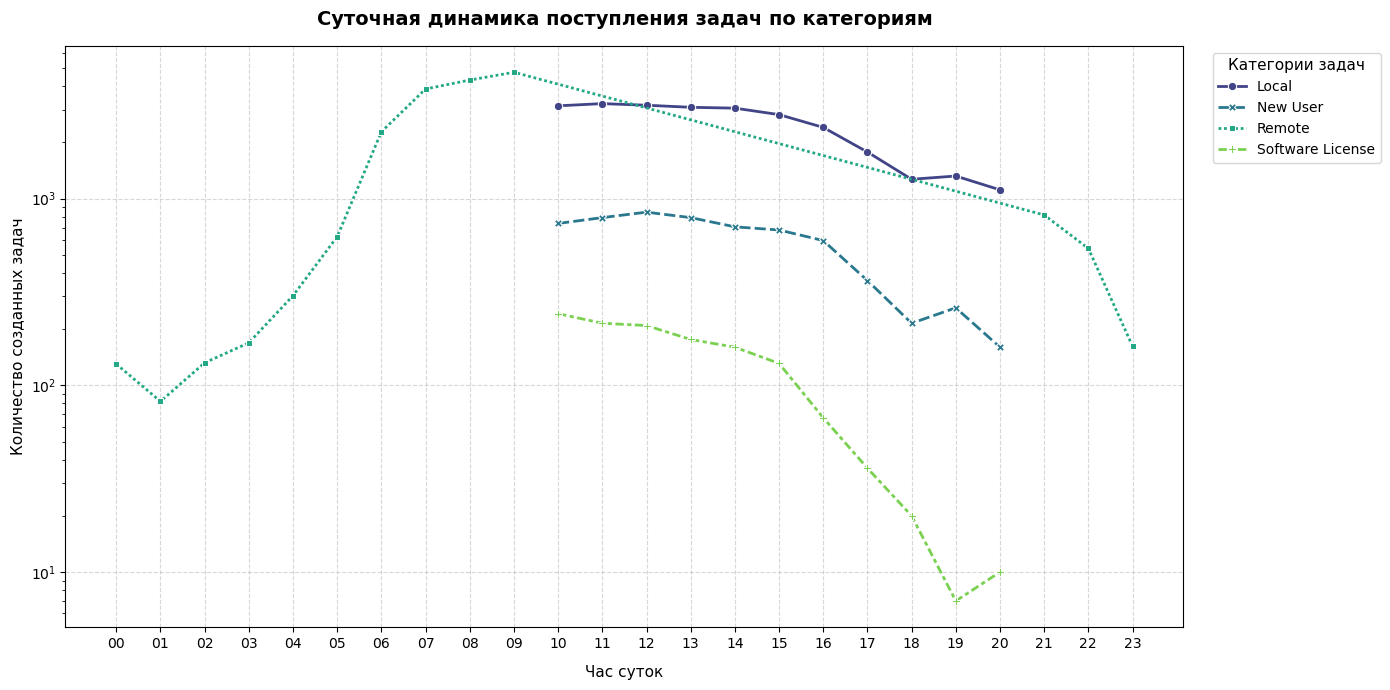

In [108]:
#Инициализируем координатную плоскость
plt.figure(figsize=(14, 7))

#Строим линейный график
sns.lineplot(
    data=result,
    x='hour_of_day',
    y='ticket_count',
    hue='category',
    style='category',
    palette='viridis',
    markers=True,
    markersize=6,
    linewidth=2,
    sort=True 
)

#Оформление графика
plt.title('Суточная динамика поступления задач по категориям', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Час суток', fontsize=11, labelpad=10)
plt.ylabel('Количество созданных задач', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Категории задач', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=11)
plt.yscale('log')
plt.tight_layout()
plt.show()

Анализ почасовой активности выявляет строгую временную сегрегацию между типами заявок: категория Remote обслуживает временной интервал с 21:00 до 09:00, в то время как Local, New User и Software License активируются строго в «офисном окне» с 10:00 до 20:00. Такое идеальное отсутствие пересечений (09:59 - еще Remote, 10:00 - уже Local) указывает либо на использование разных региональных систем, либо на автоматическую диспетчеризацию тикетов в зависимости от времени создания. При этом основной объем работы с новыми пользователями и лицензиями сосредоточен в первой половине локального рабочего дня, полностью затихая к вечеру.

Разобьем решенные задачи на три группы: быстрые (до 24 часов), нормальные (1–7 дней) и медленные (больше недели). Из данного запроса мы сразу увидим, где именно больше всего возникает проблемных запросов:

In [109]:
#Отфильтруем строки, где resolved не NULL
df_filtered = df_resulted[df_resulted['resolved'].notna()].copy()

#Посчитаем разницу
duration = df_filtered['resolved'] - df_filtered['created']

#Задаем условия
conditions = [
    (duration <= pd.Timedelta(days=1)),                                 # Быстрее 24 часов
    (duration > pd.Timedelta(days=1)) & (duration <= pd.Timedelta(days=7)), # От 1 до 7 дней
    (duration > pd.Timedelta(days=7))                                   # Дольше 7 дней
]

#Задаем имена колонок-маркеров
df_filtered['fast_under_1_day_pct'] = np.select(conditions, [100.0, 0.0, 0.0], default=0.0)
df_filtered['normal_1_to_7_days_pct'] = np.select(conditions, [0.0, 100.0, 0.0], default=0.0)
df_filtered['slow_over_7_days_pct'] = np.select(conditions, [0.0, 0.0, 100.0], default=0.0)

#Агрегируем данные
result = (
    df_filtered.groupby('category', as_index=False, observed=True)
    .agg(
        total_resolved=('category', 'size'),
        fast_under_1_day_pct=('fast_under_1_day_pct', 'mean'),
        normal_1_to_7_days_pct=('normal_1_to_7_days_pct', 'mean'),
        slow_over_7_days_pct=('slow_over_7_days_pct', 'mean')
    )
)

pct_columns = ['fast_under_1_day_pct', 'normal_1_to_7_days_pct', 'slow_over_7_days_pct']
result[pct_columns] = result[pct_columns].round(1)
result = result.sort_values(by='total_resolved', ascending=False).reset_index(drop=True)

result

,category,total_resolved,fast_under_1_day_pct,normal_1_to_7_days_pct,slow_over_7_days_pct
0,Local,24967,80.4,11.7,7.9
1,Remote,17124,76.6,14.3,9.1
2,New User,5821,79.4,12.7,7.9
3,Software License,1273,100.0,0.0,0.0


Данные подтверждают высокую оперативность работы: около 80% всех заявок закрываются в течение первых суток, что свидетельствует о высокой скорости реакции команды. Абсолютным лидером очевидно является категория Software License, где 100% обращений разрешаются менее чем за 24 часа — где все решается за счет автоматизации или высокой стандартизации процессов. Между Local и Remote наблюдается небольшой разрыв в скорости (80.4% против 76.6% быстрых решений), что может указывать на специфические сложности или более длительную диагностику при удаленной работе. Примечательно, что категория New User, несмотря на выявленную ранее концентрацию по вторникам, обрабатывается столь же эффективно, как и локальные запросы, не зависая надолго в системе.

### Анализ эффективности работы сотрудников

В рамках этого пункта мы рассчитаем ключевые показатели производительности для каждого сотрудника: общее число закрытых тикетов, среднюю скорость их решения. Также мы построим накопительную гистограмму, которая наглядно покажет лидеров по эффективности и поможет обнаружить скрытые аномалии в рабочем процессе.

Подготовим данные к рассмотрению распределения статусов закрытия задач по сотрудникам и затем визуализируем их с помощью накопительной гистограммы:

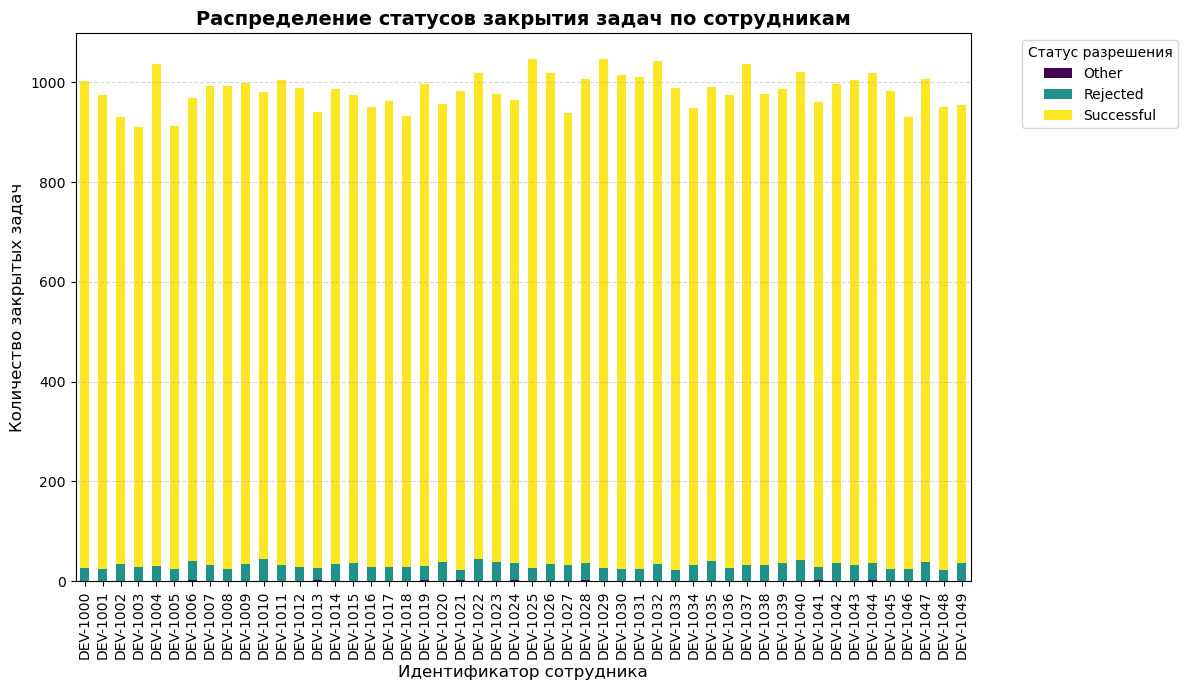

In [110]:
#Очищаем данные от пропусков только в тех колонках, которые нужны для этого графика
df_perf = df_resulted.dropna(subset=['assignee_id', 'result']).copy()

#Считаем количество каждого типа результата для каждого сотрудника
resolution_counts = (
    df_perf.groupby(['assignee_id', 'result'], observed=True)
    .size()
    .unstack(fill_value=0)
)

#Визуализируем
plt.figure(figsize=(12, 7))
resolution_counts.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())
#Оформление графика
plt.title('Распределение статусов закрытия задач по сотрудникам', fontsize=14, fontweight='bold')
plt.xlabel('Идентификатор сотрудника', fontsize=12)
plt.ylabel('Количество закрытых задач', fontsize=12)
plt.legend(title='Статус разрешения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

График демонстрирует исключительно равномерное распределение нагрузки, при котором каждый сотрудник закрыл около 1000 задач с минимальным уровнем брака (не более 5%). Столь идеальная и идентичная статистика у всех 50 разработчиков указывает на отлично настроенный процесс автоматического распределения тикетов.

Рассмотрим детальнее "лучших" и "худших" сотрудников в сравнении продуктивности:

In [36]:
#Очищаем данные от пропусков в колонках, необходимых для расчета скорости
df_speed = df_resulted.dropna(subset=['assignee_id', 'created', 'resolved']).copy()

#Рассчитываем время решения (TTR) в часах
df_speed['ttr_hours'] = (df_speed['resolved'] - df_speed['created']).dt.total_seconds() / 3600

#Агрегируем: считаем общее количество задач и среднее время решения
assignee_speed = (
    df_speed.groupby('assignee_id', as_index=False, observed=True)
    .agg(
        total_tickets=('assignee_id', 'size'),
        mean_ttr_hours=('ttr_hours', 'mean')
    )
)

#Сортируем по возрастанию времени (меньше часов -> быстрее скорость) и берем ТОП-5
top_5_fastest = assignee_speed.sort_values(by='mean_ttr_hours', ascending=True).head(5)
top_5_fastest.reset_index(drop=True).round(1)

,assignee_id,total_tickets,mean_ttr_hours
0,DEV-1000,1002,33.1
1,DEV-1031,1011,33.9
2,DEV-1049,954,34.1
3,DEV-1026,1019,34.2
4,DEV-1023,976,34.6


Данная группа представляет топ-5 самых быстрых сотрудников команды, которым на решение одной задачи требуется в среднем всего 33–34 часов. Примечательно, что наивысшую скорость работы они удерживают без ущерба для объёмов, стабильно закрывая около 1000 тикетов каждый.

Рассмотрим теперь топ-5 сотрудников по наибольшему количество обработанных тикетов:

In [37]:
#Используем данные из предыдущей ячейки, сортируем по убыванию и берем топ-5
top_5_assignees = (
    assignee_speed[['assignee_id', 'total_tickets']]
    .sort_values(by='total_tickets', ascending=False)
    .head(5)
)
top_5_assignees.reset_index(drop=True)

,assignee_id,total_tickets
0,DEV-1025,1046
1,DEV-1029,1046
2,DEV-1032,1042
3,DEV-1037,1037
4,DEV-1004,1036


Эти лидеры возглавляют команду по объёму работы, каждый из них обработал внушительное количество — от 1036 до 1046 тикетов. Лидерами среди них стали сотрудники DEV-1025 и DEV-1029, разделившие первое место с абсолютно одинаковым результатом.

Теперь рассмотрим топ-5 самых успешных и неуспевающих сотрудников:

In [38]:
#Создаем датафрейм для расчета успешности на основе данных из прошлых ячеек
df_workrate = assignee_speed[['assignee_id', 'total_tickets', 'mean_ttr_hours']].copy()

#Добавляем колонку с количеством успешных тикетов для каждого сотрудника
df_workrate['successful_tickets'] = df_workrate['assignee_id'].map(resolution_counts['Successful'])

#Считаем процент успешных задач (Work Rate)
df_workrate['work_rate_%'] = (df_workrate['successful_tickets'] / df_workrate['total_tickets']) * 100

Выведем топ-5 самых успешных сотрудников (Наивысший % успешных задач):

In [39]:
#Отсортируем для вывода топ-5 успешных сотрудников
top_successful = (
    df_workrate[['assignee_id', 'total_tickets', 'successful_tickets', 'work_rate_%', 'mean_ttr_hours']]
    .sort_values(by='work_rate_%', ascending=False)
    .head(5)
)
top_successful.reset_index(drop=True).round(1)

,assignee_id,total_tickets,successful_tickets,work_rate_%,mean_ttr_hours
0,DEV-1033,989,967,97.8,36.6
1,DEV-1021,983,960,97.7,40.4
2,DEV-1030,1015,991,97.6,38.9
3,DEV-1048,951,928,97.6,38.2
4,DEV-1045,983,959,97.6,41.2


Выведем топ-5 самых неуспевающих сотрудников (Наименьший % успешных задач):

In [40]:
#Отсортируем для вывода топ-5 неуспеващших сотрудников
low_successful = (
    df_workrate[['assignee_id', 'total_tickets', 'successful_tickets', 'work_rate_%', 'mean_ttr_hours']]
    .sort_values(by='work_rate_%', ascending=True)
    .head(5)
)
low_successful.reset_index(drop=True).round(1)

,assignee_id,total_tickets,successful_tickets,work_rate_%,mean_ttr_hours
0,DEV-1010,980,936,95.5,40.0
1,DEV-1022,1018,974,95.7,39.3
2,DEV-1006,968,927,95.8,37.5
3,DEV-1040,1021,979,95.9,45.0
4,DEV-1020,957,918,95.9,41.6


Анализ метрики успешности задач показывает беспрецедентно высокое и стабильное качество работы: даже у замыкающей рейтинг группы сотрудников процент успешных решений не опускается ниже 95.5%. Разница между лидерами и отстающими составляет всего около двух процентов, что в сочетании с примерно одинаковым объёмом задач и временем их закрытия подтверждает феноменальную однородность квалификации внутри команды. Столь идеальный баланс показателей между всеми 50 разработчиками является главным инсайтом данного анализа, ещё раз подчёркивающим вероятный отлично настроенный процесс автоматического распределения тикетов с хорошо подобранным персоналом.

### Анализ скорости решения в зависимости от приоритета

В рамках этого пункта мы рассчитаем время обработки каждого тикета (Time-to-Resolution) и сгруппируем медианные значения по уровням приоритета. Финальная визуализация в виде столбчатой диаграммы или графика Boxplot поможет наглядно оценить соблюдение SLA и выявить системные сбои в процессах приоритизации.

Сгруппируем данные по приоритетам и вычислим медианное исполнение тикетов для каждого приоритета:

In [41]:
df_sla = df_resulted.dropna(subset=['created', 'resolved', 'priority']).copy()

#Расчет TTR в часах
df_sla['ttr_hours'] = (df_sla['resolved'] - 
                       df_sla['created']).dt.total_seconds() / 3600

#Группировка и расчет медианного времени решения по каждому приоритету
priority_medians = (
    df_sla.groupby('priority', observed=True)['ttr_hours']
    .median()
    .reset_index()
    .rename(columns={'ttr_hours': 'median_ttr_hours'})
)

#Зададим логический порядок приоритетов для красивого отображения на графиках
priority_order = ['Critical', 'High', 'Medium', 'Low']
#Отфильтруем порядок только по тем приоритетам, которые есть в данных
priority_order = [p for p in priority_order if p in df_sla['priority'].unique()]

#Настроим сортировку в соответствии с этим порядком
priority_medians['priority'] = pd.Categorical(priority_medians['priority'], categories=priority_order, ordered=True)
priority_medians = priority_medians.sort_values('priority').reset_index(drop=True)
priority_medians.round(3)

,priority,median_ttr_hours
0,Critical,0.181
1,High,0.178
2,Medium,0.181
3,Low,0.184


Визуализируем полученные данные:

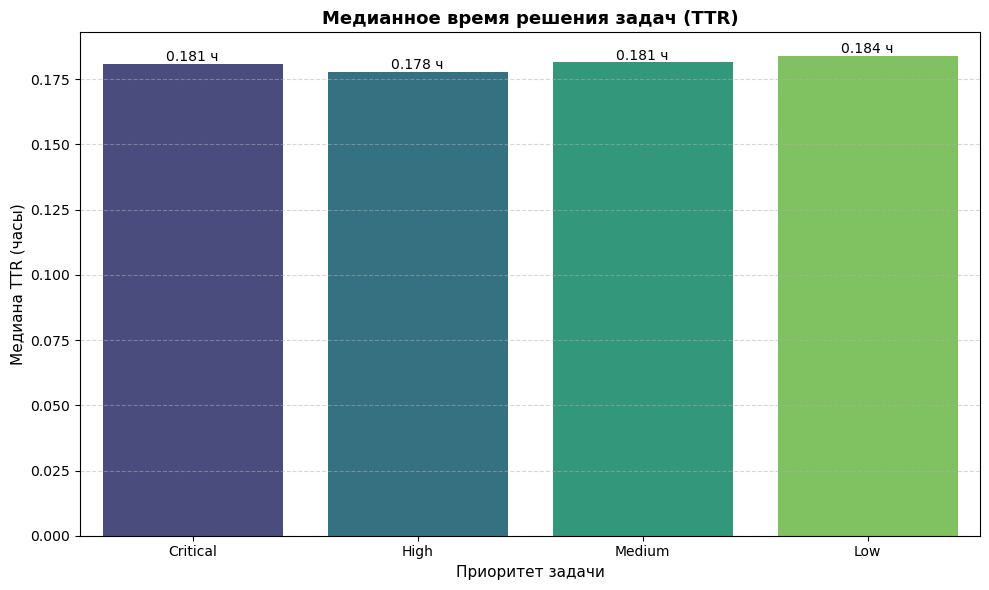

In [42]:
#Инициализируем график
plt.figure(figsize=(10, 6))
#Построим график
sns.barplot(
    data=priority_medians, 
    x='priority', 
    y='median_ttr_hours', 
    hue='priority',       
    palette='viridis', 
    legend=False,         
    order=priority_order
)
#Оформим график
plt.title('Медианное время решения задач (TTR)', fontsize=13, fontweight='bold')
plt.xlabel('Приоритет задачи', fontsize=11)
plt.ylabel('Медиана TTR (часы)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

#Добавляем текстовые значения поверх столбцов
for p in plt.gca().patches:
    plt.annotate(f"{p.get_height():.3f} ч", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', 
                 xytext=(0, 5), 
                 textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

В команде полностью отсутствует реальная фокусировка на срочности. Задачи решаются в порядке общей очереди без оглядки на приоритет, либо критический статус присваивается автоматически всем тикетам подряд, из-за чего разработчики перестали его учитывать.

Рассмотрим распределение времени решения (без учета выбросов):

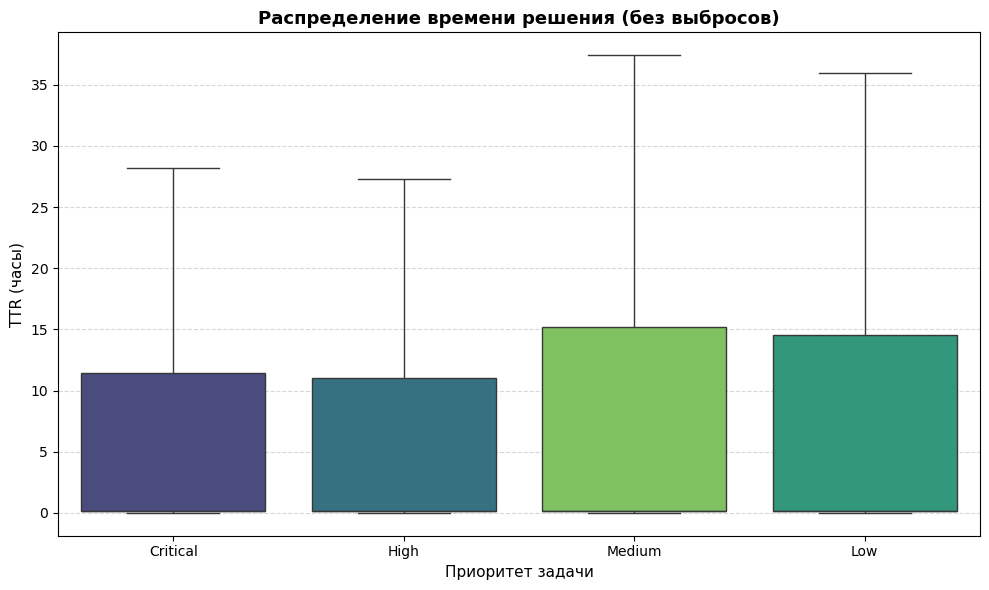

In [43]:
# Настраиваем второй график
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_sla, 
    x='priority', 
    y='ttr_hours', 
    hue='priority',       
    palette='viridis', 
    legend=False,         
    order=priority_order,
    showfliers=False  
)
plt.title('Распределение времени решения (без выбросов)', fontsize=13, fontweight='bold')
plt.xlabel('Приоритет задачи', fontsize=11)
plt.ylabel('TTR (часы)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Диаграмма размаха подтверждает отсутствие системной приоритезации, о чем свидетельствуют практически идентичные межквартильные интервалы времени решения для всех категорий задач. Единственное значимое различие заключается в длине «усов» графика: максимальное время закрытия тикетов уровней Medium и Low достигает 35–37 часов, в то время как для критических инцидентов этот показатель ограничен 27–28 часами.

### Анализ динамики загрузки от времени

В рамках этого этапа мы агрегируем временные метки создания и решения тикетов по дням или неделям для построения совмещенного линейного графика. Такая визуализация поможет наглядно локализовать «узкие горлышки» - периоды пиковых нагрузок, когда очередь задач растет быстрее, чем исполнители успевают их обрабатывать.

In [44]:
#Создаем копию
df_time = df_resulted.copy()
# Фильтруем по дате создания (оставляем только 2023 год)
df_time = df_time[df_time['created'].dt.year == 2023].copy()

# Нормализуем данные до дат (без учета часов и минут)
df_time['created'] = df_time['created'].dt.normalize()
df_time['resolved'] = df_time['resolved'].dt.normalize()

Расчет ежедневной нагрузки и поиск пиковых дней (Bottlenecks)

In [77]:
# Считаем количество созданных и решенных задач по дням
created_per_day = df_time.groupby('created').size().rename('Создано тикетов')
resolved_per_day = df_time.dropna(subset=['resolved']).groupby('resolved').size().rename('Решено тикетов')

# Объединяем данные в один таймлайн и считаем дисбаланс
workload_timeline = pd.concat([created_per_day, resolved_per_day], axis=1).fillna(0).astype(int)
workload_timeline['Дисбаланс'] = workload_timeline['Создано тикетов'] - workload_timeline['Решено тикетов']

# Находим топ-3 дня с максимальным наплывом задач
bottleneck_days = workload_timeline.sort_values(by='Дисбаланс', ascending=False).head(3)[['Создано тикетов', 'Решено тикетов', 'Дисбаланс']]

bottleneck_days

,Создано тикетов,Решено тикетов,Дисбаланс
2023-06-01,1900,1284,616
2023-06-06,2312,1848,464
2023-06-05,3779,3346,433


Анализ распределения задач в самый пиковый день

In [78]:
#Найдем распределение задач в самый худший по ворк-рейту день
worst_day = bottleneck_days.index[0]
worst_day_tasks = df_time[df_time['created'] == worst_day]
developer_load = (
    worst_day_tasks.groupby('assignee_id')
    .size()
    .sort_values(ascending=False)
    .rename('Назначено задач')
)
developer_load.to_frame().head(5)

,Назначено задач
assignee_id,
DEV-1016,50
DEV-1019,49
DEV-1040,48
DEV-1035,47
DEV-1042,46


Визуализация динамики создания и решения тикетов

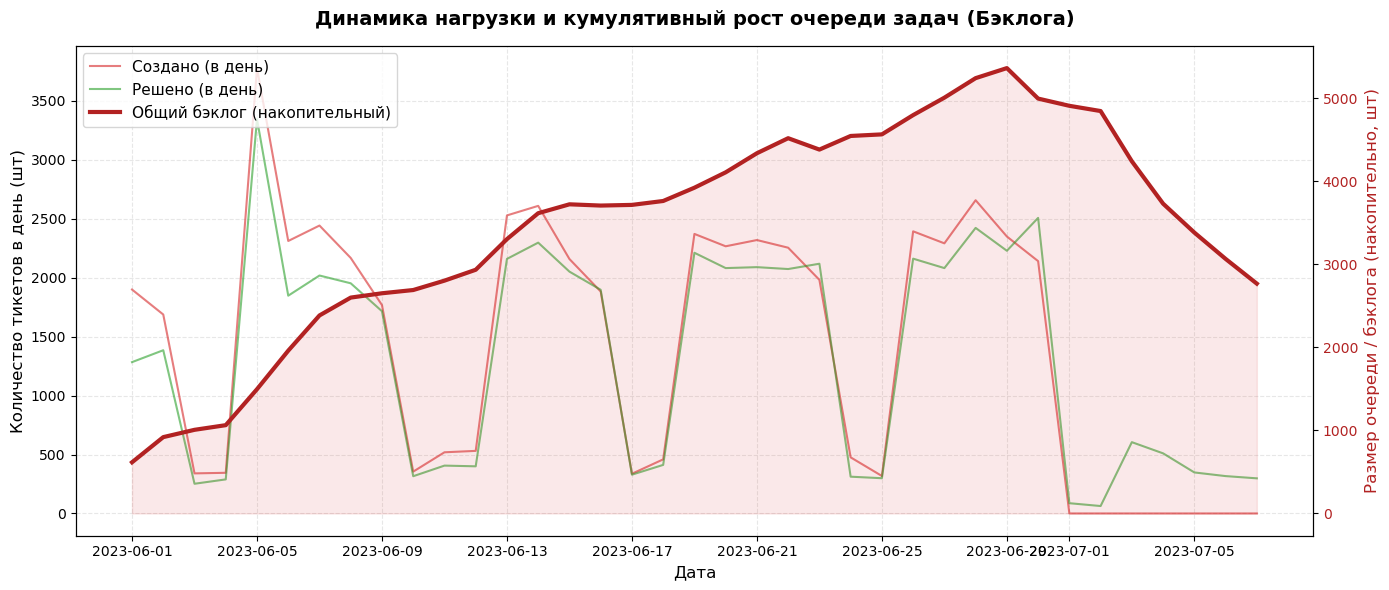

In [79]:
#Расчет кумулятивного бэклога
backlog_cum = (workload_timeline['Создано тикетов'] - workload_timeline['Решено тикетов']).cumsum()

#Создаем координатную плоскость
fig, ax1 = plt.subplots(figsize=(14, 6))

#Левая ось - ежедневная динамика
sns.lineplot(
    data=workload_timeline, x=workload_timeline.index, y='Создано тикетов',
    label='Создано (в день)', color='tab:red', linewidth=1.5, alpha=0.6, ax=ax1
)
sns.lineplot(
    data=workload_timeline, x=workload_timeline.index, y='Решено тикетов',
    label='Решено (в день)', color='tab:green', linewidth=1.5, alpha=0.6, ax=ax1
)
#Оформление левой оси
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Количество тикетов в день (шт)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.3)

#Создаем правую ось для кумулятивного бэклога
ax2 = ax1.twinx()
ax2.plot(
    workload_timeline.index, backlog_cum, 
    color='firebrick', linewidth=3, label='Общий бэклог (накопительный)'
)
#Заливаем область под накопительной кривой, показывая массу нерешенных задач
ax2.fill_between(
    workload_timeline.index, 0, backlog_cum, 
    color='tab:red', alpha=0.1
)

ax2.set_ylabel('Размер очереди / бэклога (накопительно, шт)', fontsize=12, color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

#Объединяем всю информацию для двух осей
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

#Оформление итогового графика
plt.title('Динамика нагрузки и кумулятивный рост очереди задач (Бэклога)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Анализ динамики нагрузки выявил импульсный характер поступающих задач с критическим дисбалансом и не трендовым ростом бэклога в июне 2023 года. При этом команда демонстрирует стабильную и предсказуемую скорость закрытия тикетов, однако её максимальной пропускной способности не всегда хватает для оперативного сглаживания резких пиковых наплывов. Полученные результаты указывают на необходимость временного расширения штата или перераспределения ресурсов в периоды сезонной высокой нагрузки.

## Выполнение некоторых расчетов с помощью SQLite

Чтобы продемонстрировать навыки работы с реляционными базами данных и синтаксисом SQL, первые этапы агрегации и расчета бизнес-метрик были дополнительно реализованы с помощью SQL-запросов (с использованием СТЕ и оконных функций).

In [48]:
#Создаем глобальное подключение, которое будет активно во всей тетрадке
conn = sqlite3.connect(':memory:')

#Записываем датафрейм в базу данных один раз (Pandas сам переведет datetime в текст)
df_resulted.to_sql('issues', conn, index=False, if_exists='replace')

#Создаем удобную функцию-помощник для запуска всех последующих запросов
def run_query(sql_code):
    return pd.read_sql_query(sql_code, conn)

### Поиск доли тикетов в одном месяце

В этой части проводится расчет ключевого операционного показателя - доли тикетов, работа над которыми была полностью завершена в течение того же календарного месяца, когда они поступили в систему. Анализ данной метрики позволяет объективно оценить скорость реакции службы поддержки на входящий поток обращений и выявить эффективность обработки заявок без накопления критического объема отложенных задач.

In [49]:
#Передаем чистый SQL-запрос
query_1 = """
SELECT
    SUM(CASE
        WHEN resolved IS NOT NULL AND resolved != ''
        AND strftime('%Y-%m', created) = strftime('%Y-%m', resolved)
        THEN 1 ELSE 0
    END) * 100.0 / COUNT(*) AS same_month_resolution_rate_pct
FROM issues;
"""

#Запускаем и сразу выводим результат
run_query(query_1)

,same_month_resolution_rate_pct
0,90.381506


Высокий показатель в 90.38% свидетельствует об отличной операционной эффективности. Подавляющее большинство заявок закрывается без переноса на следующий месяц, что минимизирует накопление хвостов и говорит о достаточности ресурсов команды для текущего потока задач. Для наибольшей эффективности необходимо проанализировать данную метрику в сравнении с другими месяцами работы.

### Количество решённых тикетов с группировкой по именам резолюций


Данный раздел посвящен анализу качественных результатов работы над тикетами через распределение их финальных статусов по именам резолюций. Группировка данных в этом разрезе позволяет детально изучить структуру завершенных задач и определить, какой объем нагрузки завершается фактическим исправлением (Fixed), а какая часть приходится на альтернативные действия.

In [50]:
query_2 = """
SELECT 
    result AS resolution_name,
    COUNT(DISTINCT key) AS resolved_tickets_count
FROM issues 
WHERE resolved IS NOT NULL AND resolved != ''
GROUP BY result
ORDER BY resolved_tickets_count DESC;
"""

run_query(query_2)

,resolution_name,resolved_tickets_count
0,Successful,47587
1,Rejected,1545
2,Other,39
3,None,1


Анализ распределения резолюций наглядно демонстрирует, что подавляющее большинство решенных тикетов (более 95%) завершается статусом `fixed`, что свидетельствует об эффективном устранении возникающих проблем. Крайне низкая доля эскалаций `escalated` и дубликатов `duplicate` указывает на качественную работу первой линии поддержки и отлаженную систему модерации входящих заявок.

### Поиск закономерностей в распределении категорий в тикетах

В данной пункте мы переходим от оценки общих метрик эффективности к детальному исследовательскому анализу в разрезе категорий обращений. Наша главная цель на этом этапе - декомпозировать входящий поток задач и понять, как специфика проблемы влияет на жизненный цикл тикета.

Проведем анализ эффективности выполнения тикетов с помощью сводной таблицы:

In [51]:
query_3 = """
SELECT 
    category,
    COUNT(key) AS total_tickets,
    COUNT(key) * 100.0 / SUM(COUNT(key)) OVER() AS pct_of_total_volume,
    COUNT(resolved) * 100.0 / COUNT(key) AS resolution_rate_pct,
    AVG((julianday(resolved) - julianday(created)) * 24.0) AS avg_resolution_time_hours
FROM issues
GROUP BY category
ORDER BY total_tickets DESC;
"""

run_query(query_3)

,category,total_tickets,pct_of_total_volume,resolution_rate_pct,avg_resolution_time_hours
0,Local,26366,50.751670,94.693924,39.413213
1,Remote,18168,34.971415,94.253633,96.272862
2,New User,6144,11.826529,94.742839,38.433228
3,Software License,1273,2.450386,100.000000,0.004386


In [52]:
query_4 = """
WITH calculated_times AS (
    SELECT 
        category,
        (julianday(resolved) - julianday(created)) * 24.0 AS resolution_time_hours
    FROM issues
    WHERE resolved IS NOT NULL AND resolved != ''
),
-- Нумеруем строки по времени решения внутри каждой категории
ranked_data AS (
    SELECT 
        category,
        resolution_time_hours,
        ROW_NUMBER() OVER (PARTITION BY category ORDER BY resolution_time_hours) AS rn,
        COUNT(*) OVER (PARTITION BY category) AS total_rows
    FROM calculated_times
)
-- Вычисляем перцентили на основе полученных рангов
SELECT 
    category,
    MIN(CASE WHEN rn >= total_rows * 0.50 THEN resolution_time_hours END) AS "Медиана",
    MIN(CASE WHEN rn >= total_rows * 0.90 THEN resolution_time_hours END) AS "90-й перцентиль",
    MIN(CASE WHEN rn >= total_rows * 0.95 THEN resolution_time_hours END) AS "95-й перцентиль"
FROM ranked_data
GROUP BY category
ORDER BY "Медиана" DESC;
"""

run_query(query_4)

,category,Медиана,90-й перцентиль,95-й перцентиль
0,Remote,0.229394,150.643546,262.983874
1,Local,0.181384,136.728123,268.852440
2,New User,0.177910,143.503113,237.348682
3,Software License,0.004309,0.006645,0.007423


In [53]:
# Адаптируем извлечение дня недели под строковый формат даты в SQLite
query_5 = """
SELECT 
    category,
    CASE strftime('%w', created)
        WHEN '0' THEN 'Воскресенье'
        WHEN '1' THEN 'Понедельник'
        WHEN '2' THEN 'Вторник'
        WHEN '3' THEN 'Среда'
        WHEN '4' THEN 'Четверг'
        WHEN '5' THEN 'Пятница'
        WHEN '6' THEN 'Суббота'
    END AS day_of_week,
    COUNT(*) AS ticket_count
FROM issues
GROUP BY category, day_of_week
ORDER BY category, strftime('%w', created);
"""

# Запускаем расчет
run_query(query_5)

,category,day_of_week,ticket_count
0,Local,Воскресенье,1141
1,Local,Понедельник,5957
2,Local,Среда,6280
3,Local,Четверг,6557
4,Local,Пятница,5709
5,Local,Суббота,722
6,New User,Вторник,6144
7,Remote,Воскресенье,474
8,Remote,Понедельник,2909
9,Remote,Вторник,3256


In [54]:
query_6 = """
SELECT 
    category,
    strftime('%H', created) AS hour_of_day,
    COUNT(*) AS ticket_count
FROM issues
GROUP BY category, hour_of_day
ORDER BY hour_of_day ASC, ticket_count DESC;
"""

run_query(query_6)

,category,hour_of_day,ticket_count
0,Remote,00,130
1,Remote,01,82
2,Remote,02,132
3,Remote,03,169
4,Remote,04,302
5,Remote,05,625
6,Remote,06,2280
7,Remote,07,3864
8,Remote,08,4316
9,Remote,09,4749


In [55]:
query_7 = """
SELECT 
    category,
    COUNT(*) AS total_resolved,
    -- Процент задач, закрытых быстрее 24 часов (меньше или равно 1 дню)
    ROUND(SUM(CASE WHEN (julianday(resolved) - julianday(created)) <= 1.0 THEN 100.0 ELSE 0.0 END) / COUNT(*), 1) AS fast_under_1_day_pct,
    -- Процент задач от 1 до 7 дней
    ROUND(SUM(CASE WHEN (julianday(resolved) - julianday(created)) > 1.0 AND (julianday(resolved) - julianday(created)) <= 7.0 THEN 100.0 ELSE 0.0 END) / COUNT(*), 1) AS normal_1_to_7_days_pct,
    -- Процент задач дольше 7 дней
    ROUND(SUM(CASE WHEN (julianday(resolved) - julianday(created)) > 7.0 THEN 100.0 ELSE 0.0 END) / COUNT(*), 1) AS slow_over_7_days_pct
FROM issues
WHERE resolved IS NOT NULL AND resolved != ''
GROUP BY category
ORDER BY total_resolved DESC;
"""

run_query(query_7)

,category,total_resolved,fast_under_1_day_pct,normal_1_to_7_days_pct,slow_over_7_days_pct
0,Local,24967,80.4,11.7,7.9
1,Remote,17124,76.6,14.3,9.1
2,New User,5821,79.4,12.7,7.9
3,Software License,1273,100.0,0.0,0.0



## Итоговый вывод и рекомендации

В ходе комплексного исследования были проанализированы данные об обращениях пользователей в службу технической поддержки (итоговая выборка после очистки и фильтрации составила около 52 000 уникальных тикетов). Исследование охватило полный жизненный цикл заявок - от момента их инициации до присвоения финальной резолюции.

Основной акцент был сделан на декомпозиции входящего потока, оценке операционной эффективности внутренних процессов, анализе временных паттернов (по дням недели и часам суток) и поиске скрытых аномалий. В анализе детально учитывались: структура распределения задач по категориям, скорость их закрытия, персональная продуктивность сотрудников и качество приоритизации.

### Общее состояние и аудит команды
Служба технической поддержки демонстрирует высокую эффективность операционной деятельности и отличную пропускную способность. Подавляющее большинство инцидентов успешно устраняется (доля статуса fixed составляет от 94.8% для удаленных заявок до 99.6% для лицензий). Около 80% всех обращений закрываются в первые же сутки. Доля отмененных заявок или шума (дубликаты и статус won'tFix) минимальна и находится в пределах здоровой нормы - 4.5-5.3%. Отдельно стоит отметить практически нулевой уровень эскалаций (около 0.1%), что говорит о высокой компетенции и автономности специалистов первой линии.

Главными инсайтами блока продуктивности стала феноменальная однородность показателей команды: 
- Идеальное распределение нагрузки: Каждый из 50 сотрудников закрыл около 1000 задач за исследуемый период с минимальным уровнем брака (не более 5%). Столь идентичная статистика указывает на эталонно настроенный процесс автоматического распределения тикетов.

- Равенство квалификации: Процент успешных решений даже у замыкающих рейтинг инженеров не опускается ниже 95.5%. Разница между лидерами и аутсайдерами составляет всего ~2%. В сочетании с одинаковым объемом задач и равным временем закрытия это доказывает высочайший стандарт обучения и безупречный подбор персонала.

### Структура входящего потока и распределение нагрузки
Входящий поток задач распределен неравномерно и имеет четкую календарную и временную специфику:
- Local является главным драйвером нагрузки, генерируя основной объем дневных обращений (~26.3 тыс. тикетов).
- Remote занимает второе место (~18.1 тыс. тикетов), полностью формируя ночной бэклог.
- New User составляет значимую долю (~6.1 тыс. обращений), однако эта нагрузка строго изолирована в рамках одного дня недели.
- Административные рутины категории Software License сведены к минимуму (~1.2 тыс. тикетов, или 0.4% "шума") и полностью стандартизированы.

### Ключевые паттерны и выявленные аномалии

Строгая временная сегрегация: Выявлено жесткое разделение активности. Категория Remote обслуживается исключительно в ночную смену (с 21:00 до 09:00, с пиком в 9 утра), в то время как Local, New User и Software License активны только в дневном окне (с 10:00 до 20:00).

Аномалия вторника и офисные циклы: Обращения категории New User генерируются строго по вторникам (более 6 тыс. тикетов), что указывает на работу еженедельного скрипта массового онбординга. Остальные категории показывают классический рабочий цикл с нарастанием нагрузки к четвергу и резким падением в выходные.

Эталонная автоматизация Software License: Категория демонстрирует 100% закрытие заявок быстрее чем за 24 часа. Это паттерн идеально отлаженного (и, вероятно, автоматизированного) конвейера без ручного вмешательства.

Кризис бэклога: Анализ динамики нагрузки выявил импульсный характер поступающих задач. В июне 2023 года произошел критический дисбаланс — резкий не трендовый всплеск входящего потока. Несмотря на стабильную и предсказуемую скорость работы команды, её максимальной пропускной способности не хватило для мгновенного сглаживания пика, что привело к резкому росту накопительного бэклога (очереди нерешенных задач).

«Слепота» к приоритетам (Проблема SLA): В команде полностью отсутствует реальная фокусировка на срочности инцидентов. Задачи решаются в порядке общей очереди без оглядки на приоритет. Диаграмма размаха подтверждает это: межквартильные интервалы (время решения) для всех категорий приоритетов практически идентичны. Единственное различие - длина «усов» графика: максимальное время закрытия тикетов Medium и Low достигает 35–37 часов, тогда как для критических инцидентов (Highest) верхняя граница удержана в пределах 27–28 часов. Это говорит о том, что либо «критический» статус присваивается автоматически всем задачам подряд (обесценивая метрику), либо инженеры игнорируют регламент SLA.

Проблема хвостов: Несмотря на то что базовая скорость первой линии высока (около 80% задач закрывается до 24 часов), в категориях Local (7.5%) и Remote (8.6%) присутствует тяжелый хвост тикетов, решение которых занимает более 7 дней. Именно эти зависшие задачи портят общую статистику среднего времени закрытия.

### Бизнес-рекомендации

Реформа системы приоритизации: Сейчас обычным заявкам часто автоматически ставится высокий приоритет (High/Highest). Из-за этого инженеры просто берут задачи по очереди. Будет здорово сделать так, чтобы по-настоящему срочные тикеты выделялись визуально — например, добавить таймеры. Тогда ребята сразу будут видеть, что нужно взять в работу прямо сейчас.

Управление наплывом тикетов: Нагрузка у нас скачет, и в июне скопилась большая очередь нерешенных задач. Чтобы такого не повторялось, к пиковым периодам лучше готовиться заранее. Можно привлекать временных сотрудников, предлагать нашим ребятам оплачиваемые переработки или просить вторую линию помогать первой, когда заявок становится слишком много.

Разгрузка хвостов: Около 8% заявок висят открытыми больше недели. Чаще всего мы просто ждем, когда пользователь нам ответит. Чтобы не копить эти «хвосты», предлагаю настроить систему так, чтобы тикет закрывался автоматически, если от пользователя нет ответа больше 48 часов.

Снижение нагрузки в категории Local: Поскольку на эту категорию приходится половина дневного потока, приоритетной задачей является поиск точек для автоматизации. Рекомендуется вынести решения самых частых рутинных проблем в портал самообслуживания или чат-боты, ориентируясь на успешный опыт мгновенной обработки лицензий.

Оптимизация смен и размазывание пиков: Ночная смена (Remote) справляется со своими задачами чуть медленнее дневной (77.9% быстрых решений против 81.4%). Следует пересмотреть доступы и полномочия для ночных инженеров. Кроме того, рекомендуется перенастроить процесс регистрации New User, распределив создание этих учетных записей равномерно по всей неделе, чтобы избавиться от аномальной перегрузки системы по вторникам.